# Tiingo Time Series -- MCP, CachingTiingoTool & DataFetcher Tests

Exercises the Tiingo price path end to end:
1. Direct MCP tool calls (`tiingo_series_info`, `tiingo_price_series`)
2. MCP discovery + registry
3. `CachingTiingoTool` -- fetch, cache, and normalize to the FRED observation shape
4. `TimeSeriesDataFetcherAgent` -- the agent now wraps the Tiingo tool
5. Plot the cached adjusted-close series

**Prereqs:** the meida MCP server running on `MCP_URL`, local Postgres up, and the **meida/yada (`yada-3.11.11`) kernel** selected.

In [1]:
import os
import sys
import json

sys.path.insert(0, os.path.abspath('../..'))

from apps.agentic.core.utils import set_anthropic_env
from langchain_mcp_adapters.client import MultiServerMCPClient

set_anthropic_env(filedir='../../.keys')

TICKER = 'SPY'

## 1. Direct MCP Tool Calls

Verify the meida server is reachable and the Tiingo tools return expected data.

In [2]:
from lib.mcp_client import MCPClient, MCPClientConfig
from apps.agentic.core.constants import MCP_URL

mcp_config = MCPClientConfig(url=MCP_URL)

async def call_tool(tool_name, arguments=None):
    async with MCPClient(mcp_config) as client:
        return await client.call_tool(tool_name, arguments or {})

async def list_mcp_tools():
    async with MCPClient(mcp_config) as client:
        return await client.list_tools()

tools = await list_mcp_tools()
for t in tools:
    print(f'{t.name}: {t.description}')

fred_category_children: List the child categories for a FRED category.
fred_category_series: List the series contained within a FRED category.
fred_series_info: Fetch metadata for a single FRED series.
fred_series_observations: Return observations for a series (limit defaults to 100).
fred_series_updates: Return recently updated FRED series.
list_releases: List the series that belong to a FRED release.
fred_release_series: List the series that belong to a FRED release.
tiingo_series_info: Fetch metadata for a Tiingo ticker (ETF, mutual fund, or stock), including its available date range.
tiingo_price_series: Return the end-of-day price series (OHLCV plus split/dividend-adjusted prices) for a Tiingo ticker. Provide start_date/end_date as YYYY-MM-DD for a range; omit for the latest day.


In [3]:
info = await call_tool('tiingo_series_info', {'ticker': TICKER})
if info.structuredContent:
    meta = info.structuredContent['result']
    print(f"{meta['ticker']} -- {meta['name']}")
    print(f"exchange : {meta['exchange_code']}")
    print(f"range    : {meta['start_date']} -> {meta['end_date']}")

SPY -- SPDR S&P 500 ETF Trust
exchange : NYSE
range    : 1993-01-29 -> 2026-06-18


In [4]:
result = await call_tool('tiingo_price_series',
                         {'ticker': TICKER, 'start_date': '2024-01-02', 'end_date': '2024-01-10'})
if result.structuredContent:
    data = result.structuredContent['result']
    print(f"ticker: {data['ticker']} | bars: {len(data['prices'])}\n")
    for p in data['prices']:
        print(f"{p['date'][:10]}  close={p['close']:>8.2f}  adj_close={p['adj_close']:>10.4f}  vol={p['volume']}")

ticker: SPY | bars: 7

2024-01-02  close=  472.65  adj_close=  458.8239  vol=123007793
2024-01-03  close=  468.79  adj_close=  455.0768  vol=103585866
2024-01-04  close=  467.28  adj_close=  453.6110  vol=84232169
2024-01-05  close=  467.92  adj_close=  454.2323  vol=85553758
2024-01-08  close=  474.60  adj_close=  460.7169  vol=74879074
2024-01-09  close=  473.88  adj_close=  460.0179  vol=65931439
2024-01-10  close=  476.56  adj_close=  462.6195  vol=67310640


## 2. MCP Discovery + Registry

Confirm `langchain-mcp-adapters` discovers the Tiingo tools, then populate the `MCPToolRegistry` the agents read from.

In [5]:
from typing import Any

connections: dict[str, Any] = {'fred': {'transport': 'sse', 'url': MCP_URL}}
client = MultiServerMCPClient(connections)
discovered_tools = await client.get_tools()

print(f'Discovered {len(discovered_tools)} tools:')
for t in discovered_tools:
    print(f'  {t.name}')

Discovered 9 tools:
  fred_category_children
  fred_category_series
  fred_series_info
  fred_series_observations
  fred_series_updates
  list_releases
  fred_release_series
  tiingo_series_info
  tiingo_price_series


In [6]:
from apps.agentic.core.mcp_tool_registry import MCPToolRegistry

await MCPToolRegistry.initialize(
    servers={'fred': {'transport': 'sse', 'url': MCP_URL}},
    required=['fred_series_observations'],
)

DEBUG:    MCPToolRegistry discovered 9 tools: ['fred_category_children', 'fred_category_series', 'fred_series_info', 'fred_series_observations', 'fred_series_updates', 'list_releases', 'fred_release_series', 'tiingo_series_info', 'tiingo_price_series']
INFO:     MCPToolRegistry initialized with 9 tools: ['fred_category_children', 'fred_category_series', 'fred_series_info', 'fred_series_observations', 'fred_series_updates', 'list_releases', 'fred_release_series', 'tiingo_series_info', 'tiingo_price_series']


## 3. CachingTiingoTool -- fetch, cache & normalize

The new wrapper fetches the full history, caches it in Postgres, and returns a compact `SeriesRef`.
It normalizes Tiingo's payload into the FRED observation shape so downstream plotting is unchanged.

In [7]:
from apps.agentic.db.series_cache import SeriesCache
from apps.agentic.db.series_ref import SeriesRef
from apps.agentic.agents.data.caching_tiingo_tool import CachingTiingoTool

SeriesCache.initialize()

by_name = {t.name: t for t in MCPToolRegistry.get_many(['tiingo_price_series', 'tiingo_series_info'])}
tool = CachingTiingoTool(wrapped=by_name['tiingo_price_series'], info_tool=by_name.get('tiingo_series_info'))

ref_json = await tool._arun(ticker=TICKER)
ref = SeriesRef.from_json(ref_json)
print('SeriesRef:', ref_json)

INFO:     SeriesCache initialized: postgresql://yada@localhost/yada
DEBUG:    tiingo_price_series: cache hit for tiingo:SPY
SeriesRef: {"source": "tiingo", "native_id": "SPY", "cache_id": "95a6b066-0dc9-422f-ba76-136a19d59234"}


In [9]:
entry = SeriesCache._get_by_cache_id_sync(ref.cache_id)

if entry is not None:    
    obs = entry['observations']['observations']

    print(f"source : {entry['source']} | native_id: {entry['native_id']}")
    print(f"title  : {entry['title']} | freq: {entry['frequency']}")
    print(f"count  : {entry['metadata']['observation_count']}")
    print(f"range  : {entry['observation_start']} -> {entry['observation_end']}")
    print(f"expires: {entry['expires_at']}")
    print()
    print('first obs:', obs[0])
    print('last  obs:', obs[-1])

source : tiingo | native_id: SPY
title  : SPDR S&P 500 ETF Trust | freq: daily
count  : 8404
range  : 1993-01-29 -> 2026-06-18
expires: 2026-06-22 14:09:24.032071-07:00

first obs: {'low': 43.75, 'date': '1993-01-29', 'high': 43.9687, 'open': 43.9687, 'close': 43.9375, 'value': '24.1009178563', 'volume': 1003200, 'adj_low': 23.9980689892, 'adj_high': 24.1180319078, 'adj_open': 24.1180319078, 'div_cash': 0.0, 'adj_close': 24.1009178563, 'adj_volume': 1003200.0, 'split_factor': 1.0}
last  obs: {'low': 743.86, 'date': '2026-06-18', 'high': 748.23, 'open': 747.76, 'close': 746.74, 'value': '746.74', 'volume': 80875657, 'adj_low': 743.86, 'adj_high': 748.23, 'adj_open': 747.76, 'div_cash': 1.903516, 'adj_close': 746.74, 'adj_volume': 80875657.0, 'split_factor': 1.0}


In [10]:
from datetime import datetime

# the exact contract the plot agent relies on
datetime.strptime(obs[0]['date'], '%Y-%m-%d')
float(obs[0]['value'])
print('plotter contract OK (date parses %Y-%m-%d, value is float-able)')

# second call should be a cache hit (same cache_id), lowercase ticker normalized
ref2 = SeriesRef.from_json(await tool._arun(ticker=TICKER.lower()))
print('cache hit:', ref2.cache_id == ref.cache_id)

plotter contract OK (date parses %Y-%m-%d, value is float-able)
DEBUG:    tiingo_price_series: cache hit for tiingo:SPY
cache hit: True


## 4. TimeSeriesDataFetcherAgent -- Direct Invocation

The agent now discovers and wraps the Tiingo tool alongside FRED. Ask it to fetch a ticker; it should return a `SeriesRef`.

In [12]:
from apps.agentic.agents.time_series.time_series_data_fetcher_agent import TimeSeriesDataFetcherAgent

agent = await TimeSeriesDataFetcherAgent.create()
print('Agent tools:', list(agent.tool_node.tools_by_name.keys()))

DEBUG:    TimeSeriesDataFetcherAgent using MCP tools: ['fred_series_observations', 'fred_series_info', 'tiingo_price_series', 'tiingo_series_info']
DEBUG:    TimeSeriesDataFetcherAgent prompt: 
            <instructions>
            You are a time series data fetcher agent. Use the available MCP tools to retrieve time series
            data from external data sources.

            The tools return a SeriesRef JSON object — pass it back unmodified as your response.
            Do not summarize, reformat, or interpret it.

            When fetching FRED data use the fred_series_observations tool with a limit of
            10000 to retrieve the full series.

            For ETF, mutual fund, or stock price history, use the tiingo_price_series tool
            with the ticker symbol (e.g. SPY); it returns the full adjusted-close price series.
            </instructions>
            
Agent tools: ['fred_series_observations', 'tiingo_price_series']


In [13]:
from langchain_core.messages import HumanMessage
from langchain_core.runnables import RunnableConfig
import shortuuid

state = {'messages': [HumanMessage(content=f'Fetch the {TICKER} price history from Tiingo.')]}
run_config = RunnableConfig(configurable={'thread_id': shortuuid.uuid()})

result = await agent.agent.ainvoke(state, run_config)
print(result['messages'][-1].content)

INFO:     [TimeSeriesDataFetcherAgent] routing → tiingo_price_series({'ticker': 'SPY'})
DEBUG:    tiingo_price_series: cache hit for tiingo:SPY
{"source": "tiingo", "native_id": "SPY", "cache_id": "95a6b066-0dc9-422f-ba76-136a19d59234"}


## 5. Plot the cached series

Read the cached observations the same way the plot agent does and chart the adjusted close -- a visual confirmation the whole path works.

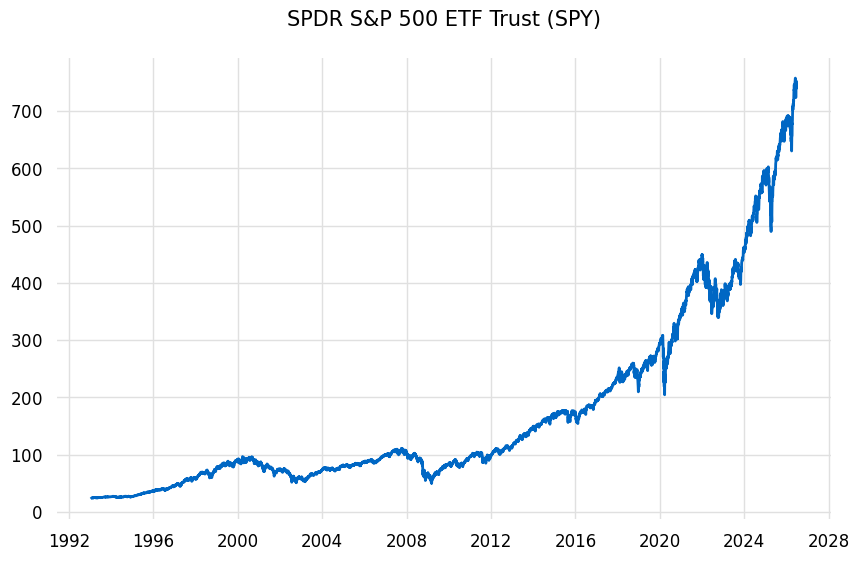

In [18]:
from lib import config
from lib.plots import curve, stack, comparison
from matplotlib import pyplot, image
import numpy

pyplot.style.use(config.glyfish_style)

entry = SeriesCache._get_by_cache_id_sync(ref.cache_id)

if entry is not None:
    obs = entry['observations']['observations']
    t = [datetime.strptime(o['date'], '%Y-%m-%d') for o in obs]
    v = [float(o['value']) for o in obs]

    curve(numpy.array(v), numpy.array(t), title=f"{entry['title']} ({entry['native_id']})", x_label='Date', y_label='Value')
